## Data Loading

In [2]:
import pandas as pd
df = pd.read_csv(r'C:\Users\Fatma\Downloads\nlp course\arabic dataset\ar_reviews_100k.tsv', sep="\t")
df.head()

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


## Data cleaning and preprocessing

In [3]:
import nltk 
import string 
import re
from nltk import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

In [4]:
df['text'] = df['text'].fillna("")
df['text'] = df['text'].str.lower()
df['text'] = df['text'].str.replace(r'[^\w\s\u0600-\u06FF]', "", regex=True)


def preprocessing(text):

    stop_words = set(stopwords.words('arabic')) 
    punctuation = set(string.punctuation)
    stemmer = SnowballStemmer("arabic")  

    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)

    new_tokens = [stemmer.stem(word) for word in tokens
        if (word not in stop_words) and (word not in punctuation)]

    return " ".join(new_tokens)


df["clean_text"] = df['text'].apply(preprocessing)

## EDA

Class Distribution analysis

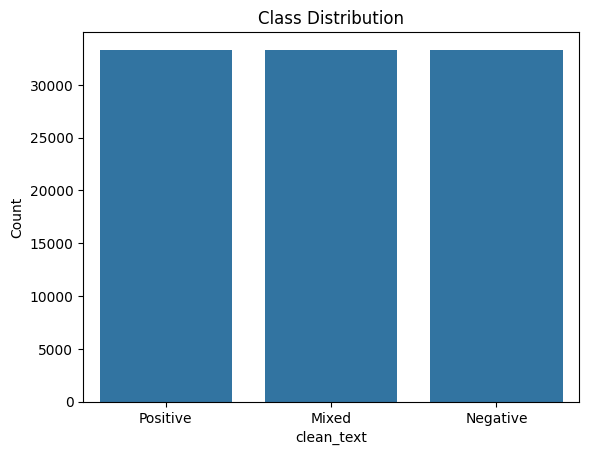

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='label',data=df)

plt.title("Class Distribution")
plt.xlabel("clean_text")
plt.ylabel("Count")
plt.show()

Text Length Distribution

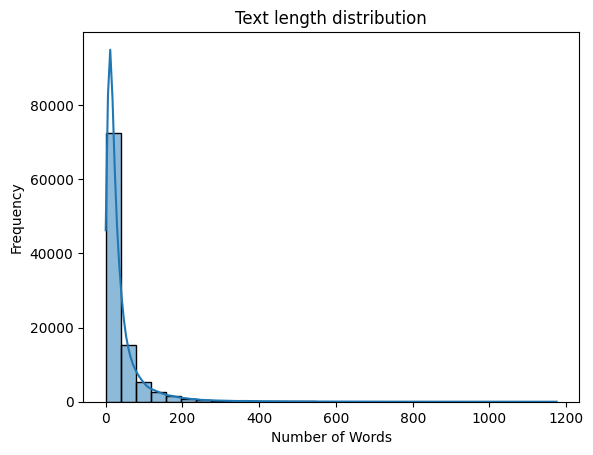

In [6]:
df['text_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

sns.histplot(df['text_length'], bins=30, kde=True)

plt.title("Text length distribution")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Most frequent words per class

In [7]:
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

for label in df['label'].unique():

    texts = df[df['label'] == label]['clean_text']

    all_words = " ".join(texts).split()

    filtered_words = [
        word for word in all_words
        if word not in stop_words
    ]

    top_words = Counter(filtered_words).most_common(5)

    print(f"\nTop words in class {label}:")
    for word, freq in top_words:
        print(word, ":", freq)


Top words in class Positive:
كتاب : 13781
روا : 13339
جدا : 11416
ان : 9483
رايع : 8481

Top words in class Mixed:
كتاب : 15664
روا : 14785
ان : 10437
جدا : 9803
انه : 7674

Top words in class Negative:
روا : 16429
كتاب : 15900
جدا : 13049
ان : 11535
انه : 8335


word cloud visualization

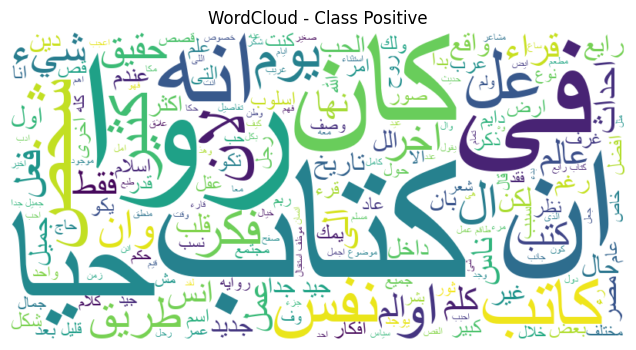

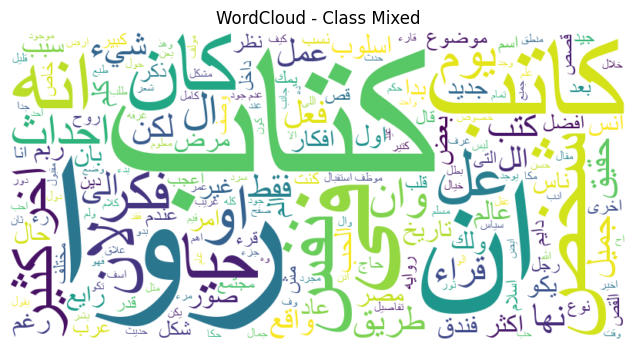

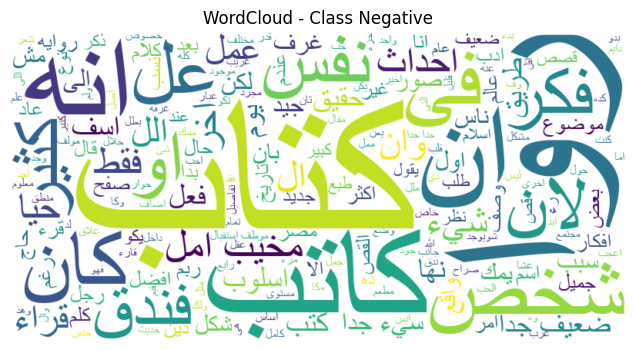

In [8]:
from wordcloud import WordCloud
from arabic_reshaper import reshape
from bidi.algorithm import get_display
for label in df['label'].unique():

    text = " ".join(df[df['label'] == label]['clean_text'])
    text = get_display(reshape(text))

    wc = WordCloud(font_path="arial.ttf",background_color="white",width=800,height=400).generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - Class {label}")
    plt.show()

## Convert data to numerical form 

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv_ar=TfidfVectorizer()
x=cv_ar.fit_transform(df['clean_text'])

In [10]:
from sklearn.preprocessing import LabelEncoder
y=df['label']
label = LabelEncoder()
y=label.fit_transform(y)

##  Split data

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

## Model training

In [12]:
from sklearn.naive_bayes import MultinomialNB
model_ar=MultinomialNB()
model_ar.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [13]:
import joblib
joblib.dump(model_ar, "arabic_model.pkl")
joblib.dump(cv_ar, "cv_ar.pkl")

['cv_ar.pkl']

## Model evaluation

In [14]:
from sklearn.metrics import classification_report
y_pred= model_ar.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.55      0.58      0.56      6722
           1       0.67      0.71      0.69      6603
           2       0.70      0.63      0.67      6675

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



<Axes: >

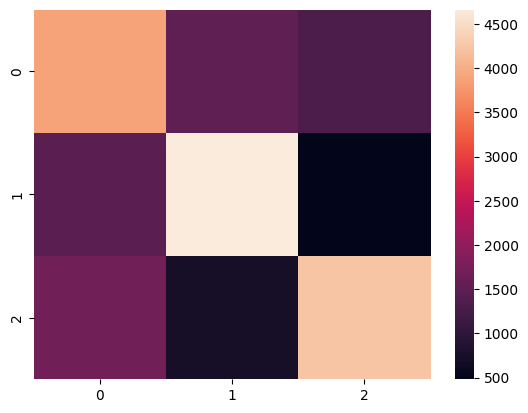

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 

sns.heatmap(confusion_matrix(y_test,y_pred))